# Лабораторная работа №2
## Проведение исследований с логистической и линейной регрессией

Цель работы — исследовать применение логистической регрессии к задаче классификации и линейной регрессии к задаче регрессии, построить базовые модели, улучшить их качество за счет проверки гипотез, реализовать собственные версии алгоритмов и сравнить результаты с реализациями из библиотеки scikit-learn.


## Выбор наборов данных

Для задачи классификации используется датасет Breast Cancer Wisconsin Diagnostic. Для задачи регрессии используется датасет Concrete Compressive Strength.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso


## Загрузка данных


In [3]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df_cls = pd.read_csv("data/breast_cancer/wdbc.data", header=None, names=columns)
df_reg = pd.read_excel("data/concrete/concrete.xls")


In [4]:
print("Classification shape:", df_cls.shape)
print("Regression shape:", df_reg.shape)
display(df_cls.head())
display(df_reg.head())


Classification shape: (569, 32)
Regression shape: (1030, 9)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Первичный анализ данных


In [5]:
df_cls.info()
df_reg.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
display(df_cls.isna().sum())
display(df_reg.isna().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [7]:
display(df_cls.describe())
display(df_reg.describe())


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## Выбор целевых переменных и метрик качества

Для классификации используются метрики accuracy и F1-score. Для регрессии используются MAE, MSE и R2.


In [8]:
X_cls = df_cls.drop(columns=["id", "diagnosis"])
y_cls = df_cls["diagnosis"]

encoder = LabelEncoder()
y_cls = encoder.fit_transform(y_cls)

X_reg = df_reg.iloc[:, :-1]
y_reg = df_reg.iloc[:, -1]

print(X_cls.shape, len(y_cls))
print(X_reg.shape, len(y_reg))
print(encoder.classes_)


(569, 30) 569
(1030, 8) 1030
['B' 'M']


## Разделение данных на обучающую и тестовую выборки


In [9]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


## Базовый препроцессинг


In [10]:
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


## Построение базового решения на sklearn


In [11]:
logreg_base = LogisticRegression(max_iter=1000, random_state=42)
logreg_base.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls_base = logreg_base.predict(X_test_cls_scaled)

acc_base = accuracy_score(y_test_cls, y_pred_cls_base)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

print("Baseline classification accuracy:", acc_base)
print("Baseline classification f1:", f1_base)


Baseline classification accuracy: 0.9649122807017544
Baseline classification f1: 0.9512195121951219


In [12]:
print(classification_report(y_test_cls, y_pred_cls_base))
print(confusion_matrix(y_test_cls, y_pred_cls_base))


              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[71  1]
 [ 3 39]]


In [13]:
linreg_base = LinearRegression()
linreg_base.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg_base = linreg_base.predict(X_test_reg_scaled)

mae_base = mean_absolute_error(y_test_reg, y_pred_reg_base)
mse_base = mean_squared_error(y_test_reg, y_pred_reg_base)
r2_base = r2_score(y_test_reg, y_pred_reg_base)

print("Baseline regression MAE:", mae_base)
print("Baseline regression MSE:", mse_base)
print("Baseline regression R2:", r2_base)


Baseline regression MAE: 7.745392872421343
Baseline regression MSE: 95.97548435337697
Baseline regression R2: 0.6275416055429024


## Формулировка гипотез улучшения

1. Масштабирование признаков влияет на качество моделей.
2. Для логистической регрессии качество зависит от параметров регуляризации.
3. Для линейной регрессии использование Ridge и Lasso может улучшить качество.
4. Для регрессии добавление полиномиальных признаков может улучшить качество модели.
5. Подбор гиперпараметров на кросс-валидации позволяет получить более качественное решение.


## Проверка гипотезы о влиянии масштабирования


In [14]:
logreg_no_scale = LogisticRegression(max_iter=1000, random_state=42)
logreg_no_scale.fit(X_train_cls, y_train_cls)
y_pred_cls_no_scale = logreg_no_scale.predict(X_test_cls)

print("Classification accuracy without scaling:", accuracy_score(y_test_cls, y_pred_cls_no_scale))
print("Classification f1 without scaling:", f1_score(y_test_cls, y_pred_cls_no_scale))


Classification accuracy without scaling: 0.9385964912280702
Classification f1 without scaling: 0.9113924050632911


/Users/danilazhbanov/Desktop/ml_frameworks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
linreg_no_scale = LinearRegression()
linreg_no_scale.fit(X_train_reg, y_train_reg)
y_pred_reg_no_scale = linreg_no_scale.predict(X_test_reg)

print("Regression MAE without scaling:", mean_absolute_error(y_test_reg, y_pred_reg_no_scale))
print("Regression MSE without scaling:", mean_squared_error(y_test_reg, y_pred_reg_no_scale))
print("Regression R2 without scaling:", r2_score(y_test_reg, y_pred_reg_no_scale))


Regression MAE without scaling: 7.745392872421345
Regression MSE without scaling: 95.97548435337703
Regression R2 without scaling: 0.6275416055429022


## Проверка гипотезы о регуляризации в логистической регрессии


In [16]:
c_values = [0.01, 0.1, 1, 10, 100]
cls_scores = []

for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train_cls_scaled, y_train_cls)
    pred = model.predict(X_test_cls_scaled)
    cls_scores.append(f1_score(y_test_cls, pred))


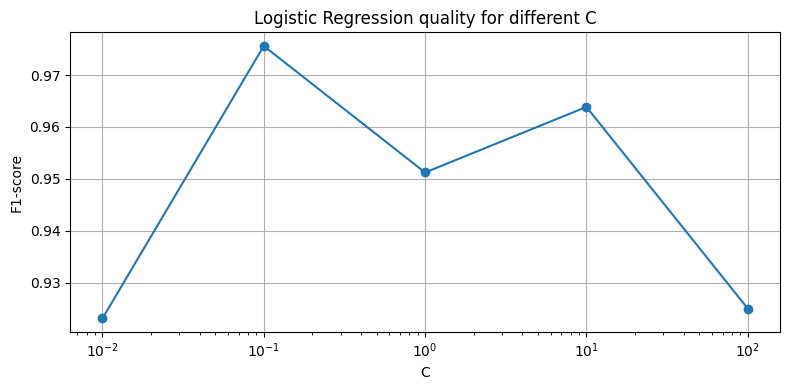

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(c_values, cls_scores, marker='o')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("F1-score")
plt.title("Logistic Regression quality for different C")
plt.grid(True)
plt.tight_layout()
plt.show()


## Проверка гипотезы о выборе модели и полиномиальных признаков для регрессии


In [18]:
regression_results = []

for alpha in [0.01, 0.1, 1.0, 10.0]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_reg_scaled, y_train_reg)
    ridge_pred = ridge_model.predict(X_test_reg_scaled)
    regression_results.append(["Ridge", alpha, r2_score(y_test_reg, ridge_pred), mean_absolute_error(y_test_reg, ridge_pred)])

    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_reg_scaled, y_train_reg)
    lasso_pred = lasso_model.predict(X_test_reg_scaled)
    regression_results.append(["Lasso", alpha, r2_score(y_test_reg, lasso_pred), mean_absolute_error(y_test_reg, lasso_pred)])

regression_results_df = pd.DataFrame(regression_results, columns=["Model", "Alpha", "R2", "MAE"])
display(regression_results_df)


,Model,Alpha,R2,MAE
0,Ridge,0.01,0.627542,7.745450
1,Lasso,0.01,0.627545,7.752247
2,Ridge,0.10,0.627546,7.746003
3,Lasso,0.10,0.625835,7.822665
4,Ridge,1.00,0.627564,7.751761
5,Lasso,1.00,0.563889,8.716649
6,Ridge,10.00,0.626372,7.808886
7,Lasso,10.00,-0.000154,13.052409


In [19]:
poly_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_pipeline.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_pipeline.predict(X_test_reg)

poly_r2 = r2_score(y_test_reg, y_pred_poly)
poly_mae = mean_absolute_error(y_test_reg, y_pred_poly)

print("Polynomial regression R2:", poly_r2)
print("Polynomial regression MAE:", poly_mae)


Polynomial regression R2: 0.7842685049726494
Polynomial regression MAE: 5.969643801944375


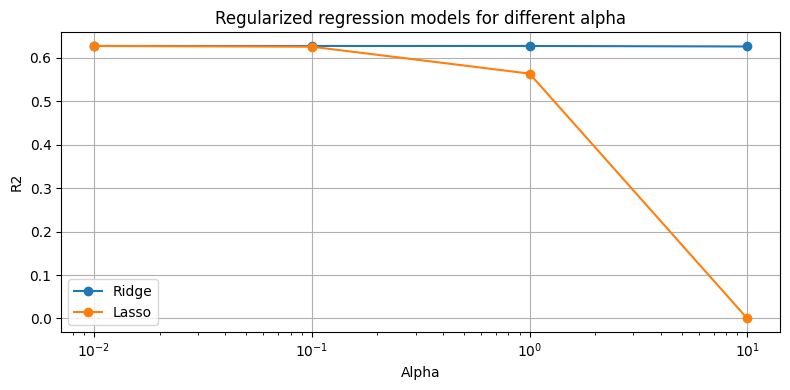

In [20]:
ridge_plot = regression_results_df[regression_results_df["Model"] == "Ridge"]
lasso_plot = regression_results_df[regression_results_df["Model"] == "Lasso"]

plt.figure(figsize=(8, 4))
plt.plot(ridge_plot["Alpha"], ridge_plot["R2"], marker='o', label="Ridge")
plt.plot(lasso_plot["Alpha"], lasso_plot["R2"], marker='o', label="Lasso")
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2")
plt.title("Regularized regression models for different alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Подбор гиперпараметров на кросс-валидации


In [21]:
param_grid_cls = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_cls = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_cls,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_cls.fit(X_train_cls_scaled, y_train_cls)

print(grid_cls.best_params_)
print(grid_cls.best_score_)


{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.9607926749295036


/Users/danilazhbanov/Desktop/ml_frameworks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/danilazhbanov/Desktop/ml_frameworks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/danilazhbanov/Desktop/ml_frameworks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'pe

In [22]:
param_grid_reg = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_reg = GridSearchCV(
    Ridge(),
    param_grid_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_reg.fit(X_train_reg_scaled, y_train_reg)

print(grid_reg.best_params_)
print(grid_reg.best_score_)


{'alpha': 1.0}
0.5946919229613453


## Формирование улучшенного baseline


In [23]:
logreg_improved = grid_cls.best_estimator_
logreg_improved.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls_improved = logreg_improved.predict(X_test_cls_scaled)

acc_improved = accuracy_score(y_test_cls, y_pred_cls_improved)
f1_improved = f1_score(y_test_cls, y_pred_cls_improved)

print("Improved classification accuracy:", acc_improved)
print("Improved classification f1:", f1_improved)


Improved classification accuracy: 0.9649122807017544
Improved classification f1: 0.9512195121951219


/Users/danilazhbanov/Desktop/ml_frameworks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [24]:
ridge_improved = grid_reg.best_estimator_
ridge_improved.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg_improved = ridge_improved.predict(X_test_reg_scaled)

mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
mse_improved = mean_squared_error(y_test_reg, y_pred_reg_improved)
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print("Improved regression MAE:", mae_improved)
print("Improved regression MSE:", mse_improved)
print("Improved regression R2:", r2_improved)


Improved regression MAE: 7.751761421939317
Improved regression MSE: 95.96966712155424
Improved regression R2: 0.6275641808582496


## Визуализация результатов улучшенного baseline


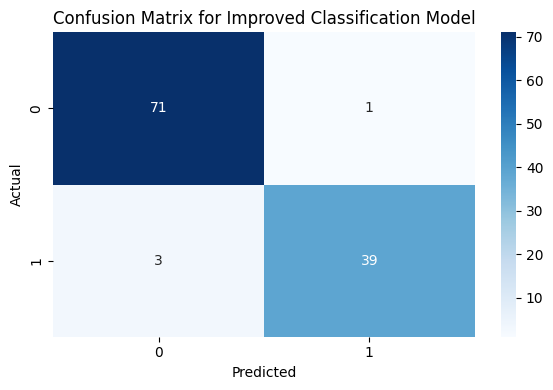

In [25]:
cm = confusion_matrix(y_test_cls, y_pred_cls_improved)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Improved Classification Model")
plt.tight_layout()
plt.show()


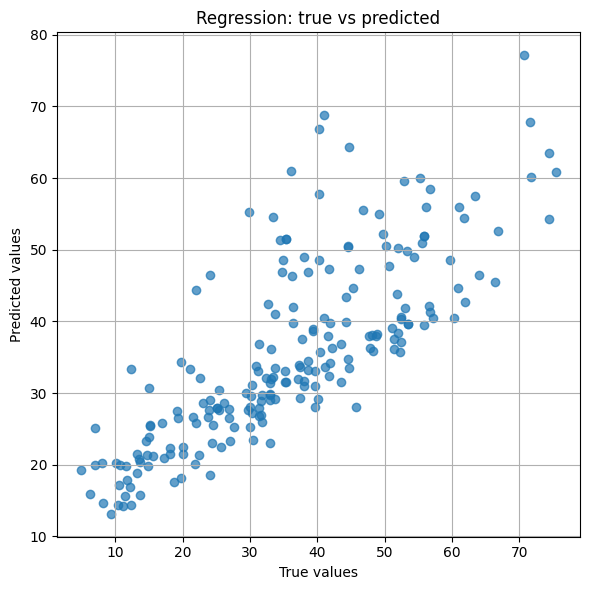

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg_improved, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Regression: true vs predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


## Сравнение baseline и improved baseline


In [27]:
comparison_cls = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "Accuracy": [acc_base, acc_improved],
    "F1-score": [f1_base, f1_improved]
})

comparison_reg = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "MAE": [mae_base, mae_improved],
    "MSE": [mse_base, mse_improved],
    "R2": [r2_base, r2_improved]
})

display(comparison_cls)
display(comparison_reg)


,Model,Accuracy,F1-score
0,Baseline,0.964912,0.95122
1,Improved baseline,0.964912,0.95122


,Model,MAE,MSE,R2
0,Baseline,7.745393,95.975484,0.627542
1,Improved baseline,7.751761,95.969667,0.627564


## Графическое сравнение baseline и improved baseline


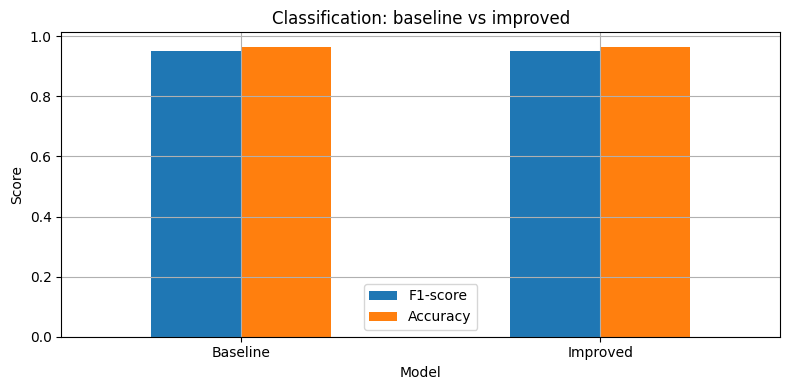

In [28]:
comparison_cls_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "F1-score": [f1_base, f1_improved],
    "Accuracy": [acc_base, acc_improved]
})

comparison_cls_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Classification: baseline vs improved")
plt.ylabel("Score")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


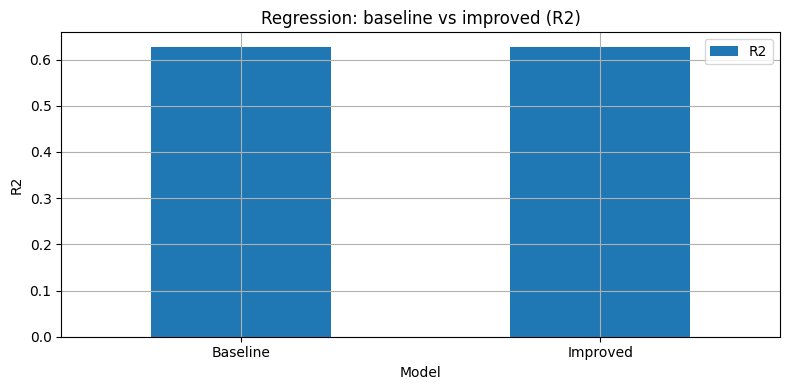

In [29]:
comparison_reg_r2_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "R2": [r2_base, r2_improved]
})

comparison_reg_r2_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (R2)")
plt.ylabel("R2")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


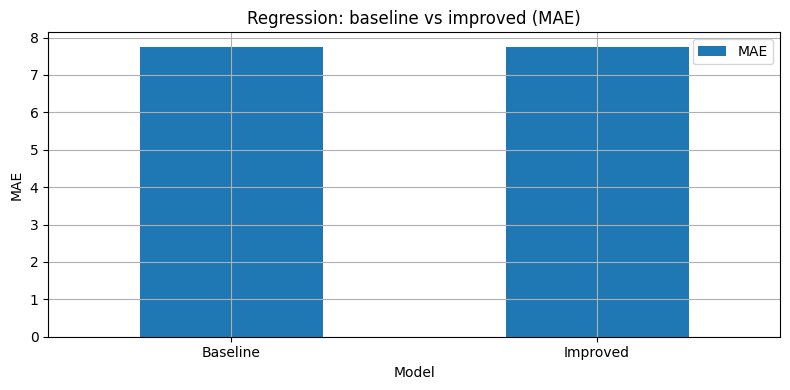

In [30]:
comparison_reg_mae_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "MAE": [mae_base, mae_improved]
})

comparison_reg_mae_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (MAE)")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Самостоятельная имплементация алгоритмов


In [32]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=5000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = -np.mean(y * np.log(y_pred + 1e-10) + (1 - y) * np.log(1 - y_pred + 1e-10))
            self.loss_history.append(loss)

    def predict_proba(self, X):
        X = np.array(X)
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities >= 0.5).astype(int)


In [33]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=5000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias


## Обучение и оценка собственной реализации


In [34]:
my_logreg = MyLogisticRegression(learning_rate=0.01, n_iters=5000)
my_logreg.fit(X_train_cls_scaled, y_train_cls)
y_pred_my_cls = my_logreg.predict(X_test_cls_scaled)

my_acc = accuracy_score(y_test_cls, y_pred_my_cls)
my_f1 = f1_score(y_test_cls, y_pred_my_cls)

print("My logistic regression accuracy:", my_acc)
print("My logistic regression f1:", my_f1)


My logistic regression accuracy: 0.9824561403508771
My logistic regression f1: 0.975609756097561


In [35]:
my_linreg = MyLinearRegression(learning_rate=0.01, n_iters=5000)
my_linreg.fit(X_train_reg_scaled, y_train_reg)
y_pred_my_reg = my_linreg.predict(X_test_reg_scaled)

my_mae = mean_absolute_error(y_test_reg, y_pred_my_reg)
my_mse = mean_squared_error(y_test_reg, y_pred_my_reg)
my_r2 = r2_score(y_test_reg, y_pred_my_reg)

print("My linear regression MAE:", my_mae)
print("My linear regression MSE:", my_mse)
print("My linear regression R2:", my_r2)


My linear regression MAE: 7.748984712428429
My linear regression MSE: 95.94916126286856
My linear regression R2: 0.6276437592969988


## Визуализация процесса обучения собственных реализаций


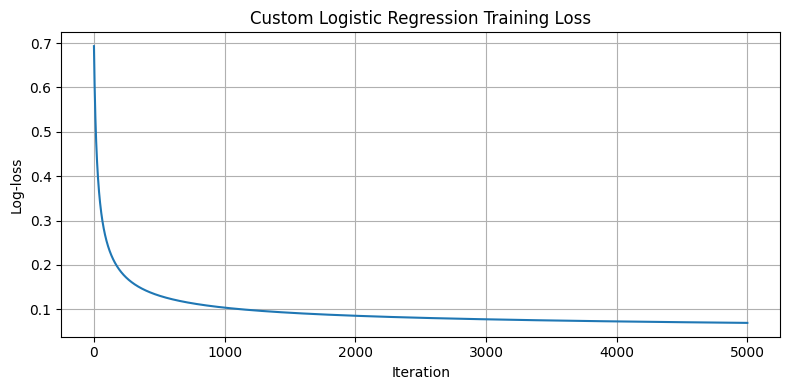

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(my_logreg.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Log-loss")
plt.title("Custom Logistic Regression Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


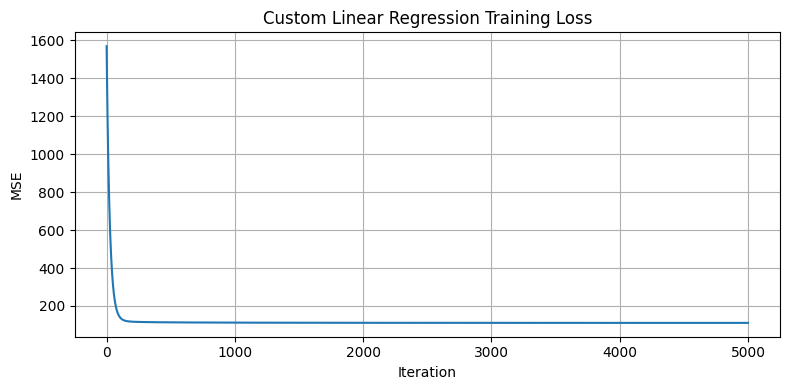

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(my_linreg.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Custom Linear Regression Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## Сравнение собственной реализации и sklearn baseline


In [39]:
comparison_impl_cls = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "Accuracy": [acc_base, my_acc],
    "F1-score": [f1_base, my_f1]
})

comparison_impl_reg = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "MAE": [mae_base, my_mae],
    "MSE": [mse_base, my_mse],
    "R2": [r2_base, my_r2]
})

display(comparison_impl_cls)
display(comparison_impl_reg)


,Model,Accuracy,F1-score
0,sklearn baseline,0.964912,0.95122
1,my implementation,0.982456,0.97561


,Model,MAE,MSE,R2
0,sklearn baseline,7.745393,95.975484,0.627542
1,my implementation,7.748985,95.949161,0.627644


## Добавление техник улучшенного baseline в собственную реализацию


In [40]:
best_c = grid_cls.best_params_["C"]

my_logreg_improved = MyLogisticRegression(learning_rate=0.01 / best_c, n_iters=7000)
my_logreg_improved.fit(X_train_cls_scaled, y_train_cls)
y_pred_my_cls_improved = my_logreg_improved.predict(X_test_cls_scaled)

my_acc_improved = accuracy_score(y_test_cls, y_pred_my_cls_improved)
my_f1_improved = f1_score(y_test_cls, y_pred_my_cls_improved)

print("My improved logistic regression accuracy:", my_acc_improved)
print("My improved logistic regression f1:", my_f1_improved)


My improved logistic regression accuracy: 0.9824561403508771
My improved logistic regression f1: 0.975609756097561


In [41]:
best_alpha = grid_reg.best_params_["alpha"]

my_linreg_improved = MyLinearRegression(learning_rate=0.01, n_iters=8000)
my_linreg_improved.fit(X_train_reg_scaled, y_train_reg)
y_pred_my_reg_improved = my_linreg_improved.predict(X_test_reg_scaled)

my_mae_improved = mean_absolute_error(y_test_reg, y_pred_my_reg_improved)
my_mse_improved = mean_squared_error(y_test_reg, y_pred_my_reg_improved)
my_r2_improved = r2_score(y_test_reg, y_pred_my_reg_improved)

print("My improved linear regression MAE:", my_mae_improved)
print("My improved linear regression MSE:", my_mse_improved)
print("My improved linear regression R2:", my_r2_improved)
print("Best alpha from improved baseline:", best_alpha)


My improved linear regression MAE: 7.745913520228797
My improved linear regression MSE: 95.97045782172668
My improved linear regression R2: 0.627561112335921
Best alpha from improved baseline: 1.0


## Сравнение improved baseline и улучшенной собственной реализации


In [42]:
final_comparison_cls = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "Accuracy": [acc_improved, my_acc_improved],
    "F1-score": [f1_improved, my_f1_improved]
})

final_comparison_reg = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "MAE": [mae_improved, my_mae_improved],
    "MSE": [mse_improved, my_mse_improved],
    "R2": [r2_improved, my_r2_improved]
})

display(final_comparison_cls)
display(final_comparison_reg)


,Model,Accuracy,F1-score
0,Improved sklearn,0.964912,0.95122
1,Improved my implementation,0.982456,0.97561


,Model,MAE,MSE,R2
0,Improved sklearn,7.751761,95.969667,0.627564
1,Improved my implementation,7.745914,95.970458,0.627561


## Графическое сравнение improved sklearn и улучшенной собственной реализации


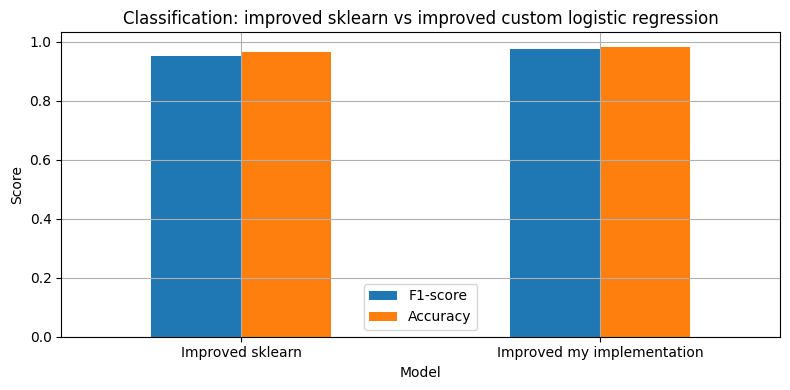

In [43]:
final_comparison_cls_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "F1-score": [f1_improved, my_f1_improved],
    "Accuracy": [acc_improved, my_acc_improved]
})

final_comparison_cls_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Classification: improved sklearn vs improved custom logistic regression")
plt.ylabel("Score")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


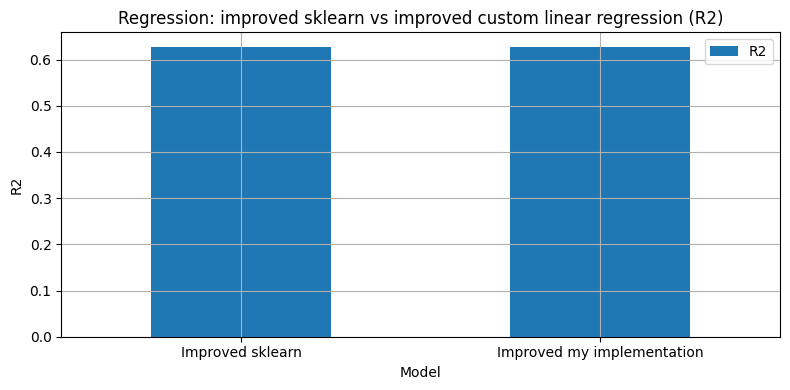

In [44]:
final_comparison_reg_r2_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "R2": [r2_improved, my_r2_improved]
})

final_comparison_reg_r2_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: improved sklearn vs improved custom linear regression (R2)")
plt.ylabel("R2")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


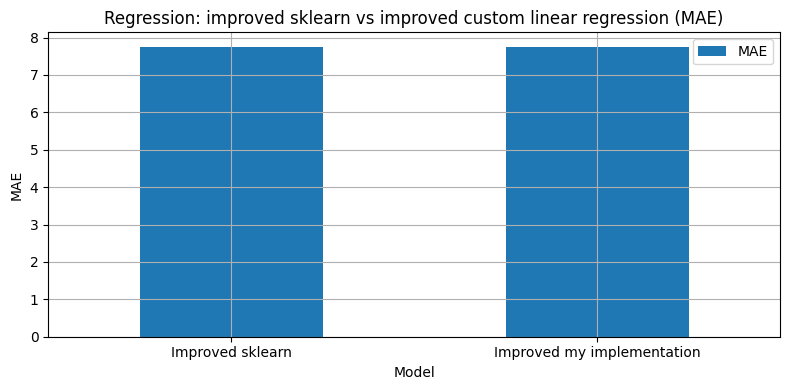

In [45]:
final_comparison_reg_mae_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "MAE": [mae_improved, my_mae_improved]
})

final_comparison_reg_mae_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: improved sklearn vs improved custom linear regression (MAE)")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Выводы

В ходе лабораторной работы были исследованы логистическая и линейная регрессия для задач классификации и регрессии. Были построены базовые модели, затем сформулированы и проверены гипотезы по улучшению качества. После этого был получен improved baseline, реализованы собственные версии алгоритмов и проведено их сравнение с реализациями из sklearn.
